<a href="https://colab.research.google.com/github/muhammadabdurrehmanmaqsood/brain-tumor-classifier/blob/main/notebooks/03_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from google.colab import drive

# Mount Google Drive safely
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print("Drive already mounted!")

Mounted at /content/drive


In [2]:
# 1. Extract the dataset from Drive to Colab's fast local storage
!unzip -q -o /content/drive/MyDrive/brain_tumor_project/data/brain-tumor-classification-mri.zip -d /content/dataset/

# 2. Import required libraries
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# 3. Define the evaluation transformations (Strictly NO data augmentation here)
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 4. Load the full dataset
full_train_dataset = datasets.ImageFolder(
    root='/content/dataset/Training',
    transform=val_transforms
)

# 5. Recreate the EXACT Validation Split (85% Train, 15% Val)
train_size = int(0.85 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

# CRITICAL: This generator seed must match your training notebook perfectly
generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size], generator=generator)

# 6. Package the validation data into a DataLoader
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Validation data ready. Total validation batches: {len(val_loader)}")

Validation data ready. Total validation batches: 14


In [3]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Initialize the architecture
model = models.resnet50(weights=None) # We don't need pretrained ImageNet weights anymore
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 4)

# 2. Load your custom, fine-tuned weights from Google Drive
model_path = '/content/drive/MyDrive/brain_tumor_project/models/resnet50_best.pth'
model.load_state_dict(torch.load(model_path))
model = model.to(device)

# 3. CRITICAL: Set to evaluation mode to disable dropout and batch normalization
model.eval()
print("Best model loaded successfully.")

Best model loaded successfully.


In [4]:
all_preds = []
all_labels = []

# Disable gradient calculation to save memory and speed up inference
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        # Move tensors back to CPU and convert to standard numpy arrays
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Predictions generated.")

Predictions generated.


--- Classification Report ---
                  precision    recall  f1-score   support

    glioma_tumor       0.97      0.98      0.98       116
meningioma_tumor       0.96      0.95      0.96       129
        no_tumor       0.97      1.00      0.99        70
 pituitary_tumor       0.98      0.97      0.97       116

        accuracy                           0.97       431
       macro avg       0.97      0.98      0.97       431
    weighted avg       0.97      0.97      0.97       431



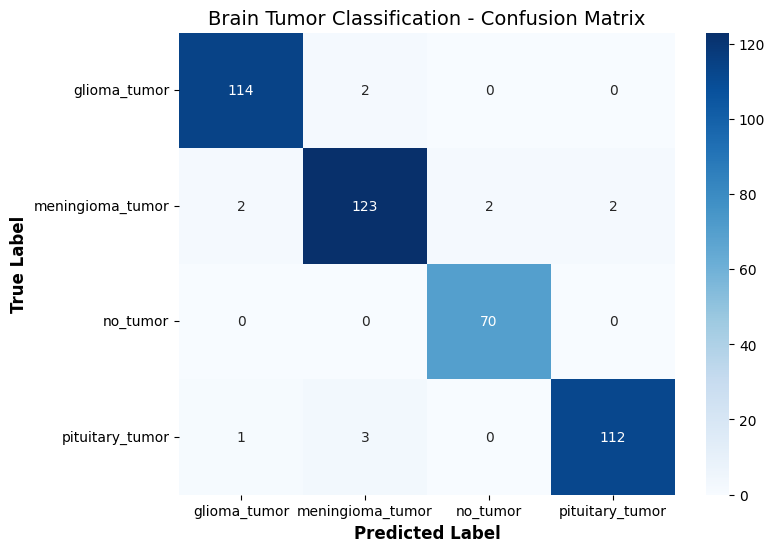

In [5]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Retrieve class names from the dataset (e.g., Glioma, Meningioma, No Tumor, Pituitary)
class_names = val_dataset.dataset.classes

# 1. Print the Classification Report
print("--- Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=class_names))

# 2. Generate and Plot the Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Brain Tumor Classification - Confusion Matrix', fontsize=14)

# Save the plot to Drive so you can easily add it to your GitHub README later
plt.savefig('/content/drive/MyDrive/brain_tumor_project/confusion_matrix.png')
plt.show()